In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
round((df.isnull().sum()/df.shape[0])*100,2)

,0
PassengerId,0.0
Survived,0.0
Pclass,0.0
Name,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Ticket,0.0
Fare,0.0


In [ ]:
df.drop("Cabin",axis=1,inplace=True)# permant save

<Axes: ylabel='Age'>

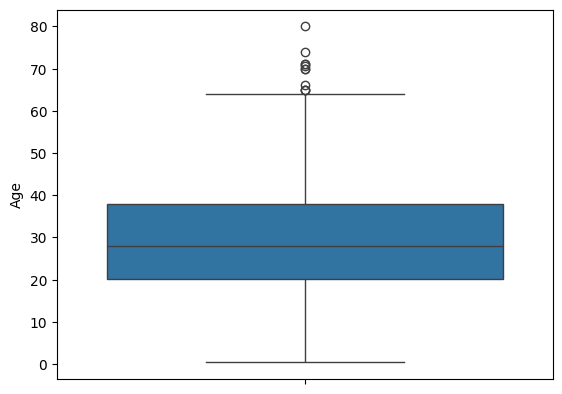

In [ ]:
import seaborn as sns
sns.boxplot(df["Age"])

In [ ]:
df.Age.fillna(df.Age.median(),inplace=True)

/tmp/ipython-input-1634043521.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df.Age.median(),inplace=True)


In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [ ]:
df.Embarked.fillna(df.Embarked.mode()[0],inplace=True)

/tmp/ipython-input-2413181878.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Embarked.fillna(df.Embarked.mode()[0],inplace=True)


In [ ]:
round((df.isnull().sum()/891)*100,2)

,0
PassengerId,0.0
Survived,0.0
Pclass,0.0
Name,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Ticket,0.0
Fare,0.0


In [ ]:
round((df.isnull().sum(axis=1)/891)*100,2) > 7

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


# Feature Engineering

In [ ]:
df['new'] = df.Age/2 # this is not a feature eng

In [ ]:
df.drop("new",axis=1,inplace=True)

In [ ]:
df['Family_Size'] = df.Parch+df.SibSp+1

In [ ]:
df['senior'] = df.Age.apply(lambda x :1  if x>60 else 0)

In [ ]:
df['Gender_age'] = df.apply(lambda x:"child" if x['Age']<15 else x["Sex"],axis=1)

In [ ]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_Size,senior,Gender_age
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,0,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,0,male
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,1,0,male
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,1,0,male
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,5,0,child
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,3,0,female
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,2,0,child


In [ ]:
df.Gender_age.value_counts()

,count
Gender_age,
male,538
female,275
child,78


In [ ]:
df.drop(['PassengerId','Name','SibSp','Parch','Ticket','Sex'],axis=1,inplace=True)

In [ ]:
df

,Survived,Pclass,Age,Fare,Embarked,Family_Size,senior,Gender_age
0,0,3,22.0,7.2500,S,2,0,male
1,1,1,38.0,71.2833,C,2,0,female
2,1,3,26.0,7.9250,S,1,0,female
3,1,1,35.0,53.1000,S,2,0,female
4,0,3,35.0,8.0500,S,1,0,male
...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,S,1,0,male
887,1,1,19.0,30.0000,S,1,0,female
888,0,3,28.0,23.4500,S,4,0,female
889,1,1,26.0,30.0000,C,1,0,male


In [ ]:
df = pd.get_dummies(df,columns=['Embarked','Gender_age'],drop_first=True)

In [ ]:
df

,Survived,Pclass,Age,Fare,Family_Size,senior,Embarked_Q,Embarked_S,Gender_age_female,Gender_age_male
0,0,3,22.0,7.2500,2,0,False,True,False,True
1,1,1,38.0,71.2833,2,0,False,False,True,False
2,1,3,26.0,7.9250,1,0,False,True,True,False
3,1,1,35.0,53.1000,2,0,False,True,True,False
4,0,3,35.0,8.0500,1,0,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,1,0,False,True,False,True
887,1,1,19.0,30.0000,1,0,False,True,True,False
888,0,3,28.0,23.4500,4,0,False,True,True,False
889,1,1,26.0,30.0000,1,0,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (712, 9)
Shape of X_test: (179, 9)
Shape of y_train: (712,)
Shape of y_test: (179,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data (X_train) and transform both X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easier inspection (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train_scaled head:")
display(X_train_scaled.head())
print("\nX_test_scaled head:")
display(X_test_scaled.head())

X_train_scaled head:


,Pclass,Age,Fare,Family_Size,senior,Embarked_Q,Embarked_S,Gender_age_female,Gender_age_male
331,-1.614136,1.253641,-0.078684,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
733,-0.400551,-0.477284,-0.377145,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
382,0.813034,0.215086,-0.474867,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
704,0.813034,-0.246494,-0.476230,0.040096,-0.141624,-0.303355,0.592489,-0.655529,0.802709
813,0.813034,-1.785093,-0.025249,3.013909,-0.141624,-0.303355,0.592489,-0.655529,-1.245781



X_test_scaled head:


,Pclass,Age,Fare,Family_Size,senior,Embarked_Q,Embarked_S,Gender_age_female,Gender_age_male
709,0.813034,-0.092634,-0.333901,0.634859,-0.141624,-0.303355,-1.687794,-0.655529,0.802709
439,-0.400551,0.138156,-0.425284,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
840,0.813034,-0.708074,-0.474867,-0.554666,-0.141624,-0.303355,0.592489,-0.655529,0.802709
720,-0.400551,-1.785093,0.007966,0.040096,-0.141624,-0.303355,0.592489,-0.655529,-1.245781
39,0.813034,-1.169653,-0.411002,0.040096,-0.141624,-0.303355,-1.687794,-0.655529,-1.245781


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)

# Fit the model on the scaled training data
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = log_reg_model.predict(X_test_scaled)



In [ ]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

In [ ]:
(y_pred==y_test).sum() # correct matching

np.int64(145)

In [ ]:
y_test.shape

(179,)

In [ ]:
(y_pred==y_test).sum() /y_test.shape

array([0.81005587])

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8100558659217877

In [ ]:
y_pred_train = log_reg_model.predict(X_train_scaled)

accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_train

0.8314606741573034

In [ ]:
# We do not need regularizatyion

In [ ]:
log_reg_model.predict_proba(X_test_scaled)

array([[0.9313424 , 0.0686576 ],
       [0.81812847, 0.18187153],
       [0.9077035 , 0.0922965 ],
       [0.17829447, 0.82170553],
       [0.27877447, 0.72122553],
       [0.04952384, 0.95047616],
       [0.28096199, 0.71903801],
       [0.95028353, 0.04971647],
       [0.25370239, 0.74629761],
       [0.10833263, 0.89166737],
       [0.71049816, 0.28950184],
       [0.92850937, 0.07149063],
       [0.63346061, 0.36653939],
       [0.87131743, 0.12868257],
       [0.82535952, 0.17464048],
       [0.07168838, 0.92831162],
       [0.72266568, 0.27733432],
       [0.28090658, 0.71909342],
       [0.80978886, 0.19021114],
       [0.65582824, 0.34417176],
       [0.91152792, 0.08847208],
       [0.64153147, 0.35846853],
       [0.35089573, 0.64910427],
       [0.90732565, 0.09267435],
       [0.91340898, 0.08659102],
       [0.71681655, 0.28318345],
       [0.5388869 , 0.4611131 ],
       [0.81683674, 0.18316326],
       [0.70247074, 0.29752926],
       [0.29969538, 0.70030462],
       [0.

In [ ]:

# Define lambda values
lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
results = {}

for lam in lambdas:
    C = 1 / lam   # C is inverse of lambda

    model = LogisticRegression(
        C=C,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results[lam] = acc

    print(f"Lambda: {lam:<6} | C: {C:<8} | Accuracy: {acc:.4f}")

# Best lambda
best_lambda = max(results, key=results.get)
print(f"\nBest Lambda: {best_lambda} with Accuracy: {results[best_lambda]:.4f}")

Lambda: 0.0001 | C: 10000.0  | Accuracy: 0.8101
Lambda: 0.001  | C: 1000.0   | Accuracy: 0.8101
Lambda: 0.01   | C: 100.0    | Accuracy: 0.8101
Lambda: 0.1    | C: 10.0     | Accuracy: 0.8101
Lambda: 1      | C: 1.0      | Accuracy: 0.8101
Lambda: 10     | C: 0.1      | Accuracy: 0.7933

Best Lambda: 0.0001 with Accuracy: 0.8101


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train.shape

(712, 9)

In [ ]:
X_test.shape

(179, 9)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [ ]:
X_train.shape

(569, 9)

In [ ]:
X_val.shape

(143, 9)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
results = {}

for lam in lambdas:
    C = 1 / lam   # inverse of lambda

    model = LogisticRegression(
        l1_ratio=0,# a pure L2-penalty.
        C=C,


        random_state=42
    )

    # Train on TRAIN set
    model.fit(X_train_scaled, y_train)

    # Validate on VAL set
    y_val_pred = model.predict(X_val_scaled)

    acc = accuracy_score(y_val, y_val_pred)
    results[lam] = acc

    print(f"Lambda: {lam:<6} | C: {C:<8} | Val Accuracy: {acc:.4f}")


Lambda: 0.0001 | C: 10000.0  | Val Accuracy: 0.8252
Lambda: 0.001  | C: 1000.0   | Val Accuracy: 0.8252
Lambda: 0.01   | C: 100.0    | Val Accuracy: 0.8252
Lambda: 0.1    | C: 10.0     | Val Accuracy: 0.8252
Lambda: 1      | C: 1.0      | Val Accuracy: 0.8112
Lambda: 10     | C: 0.1      | Val Accuracy: 0.8182


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

In [ ]:
best_lambda = max(results, key=results.get)
best_C = 1 / best_lambda

print(f"\nBest Lambda: {best_lambda}")
print(f"Best Validation Accuracy: {results[best_lambda]:.4f}")


Best Lambda: 0.0001
Best Validation Accuracy: 0.8252


In [ ]:
lasso - l1_ratio -0 ,ridge l1_ratio -1

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [ ]:
X_train.shape

(569, 9)

In [ ]:
569/5

113.8

In [ ]:
113.8*4

455.2

In [ ]:
# Fixed lambda
lambda_val = 0.0001
C = 1 / lambda_val

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    print(f"\nFold {fold}:")
    print("Train size:", len(train_idx))
    print("Val size:", len(val_idx))

    # ✅ USE .iloc
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            penalty='l2',
            C=C,
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Fold 1:
Train size: 455
Val size: 114
Fold 1 Accuracy: 0.7544

Fold 2:
Train size: 455
Val size: 114
Fold 2 Accuracy: 0.8684

Fold 3:
Train size: 455
Val size: 114
Fold 3 Accuracy: 0.8421

Fold 4:
Train size: 455
Val size: 114
Fold 4 Accuracy: 0.8421

Fold 5:
Train size: 456
Val size: 113
Fold 5 Accuracy: 0.8319
